In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from pathlib import Path

query_path = Path("../database/queries")
output_path = Path("../visuals/exports")
output_path.mkdir(parents=True, exist_ok=True)

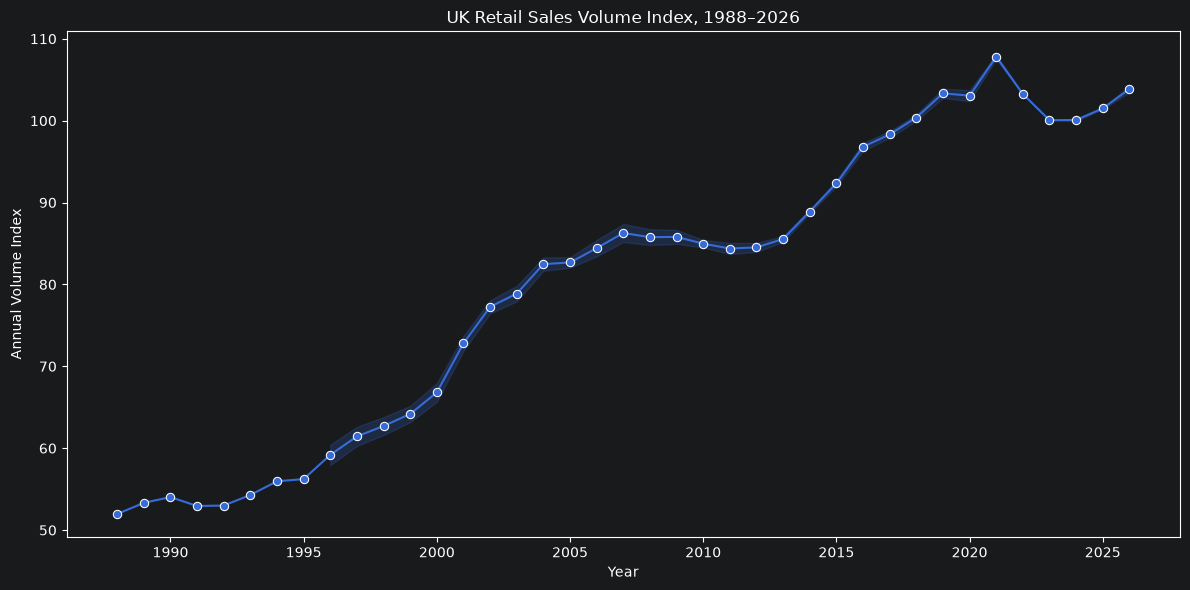

In [71]:
q1_sql = query_path.joinpath("volume_trend_1988_2026.sql").read_text()
q1 = pd.read_sql(text(q1_sql), engine)
q1.head()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=q1,
    x="year",
    y="annual_volume_index",
    marker="o"
)

plt.title("UK Retail Sales Volume Index, 1988–2026")
plt.xlabel("Year")
plt.ylabel("Annual Volume Index")

plt.tight_layout()
plt.savefig(output_path / "volume_trend.png", dpi=300, bbox_inches="tight")
plt.show()

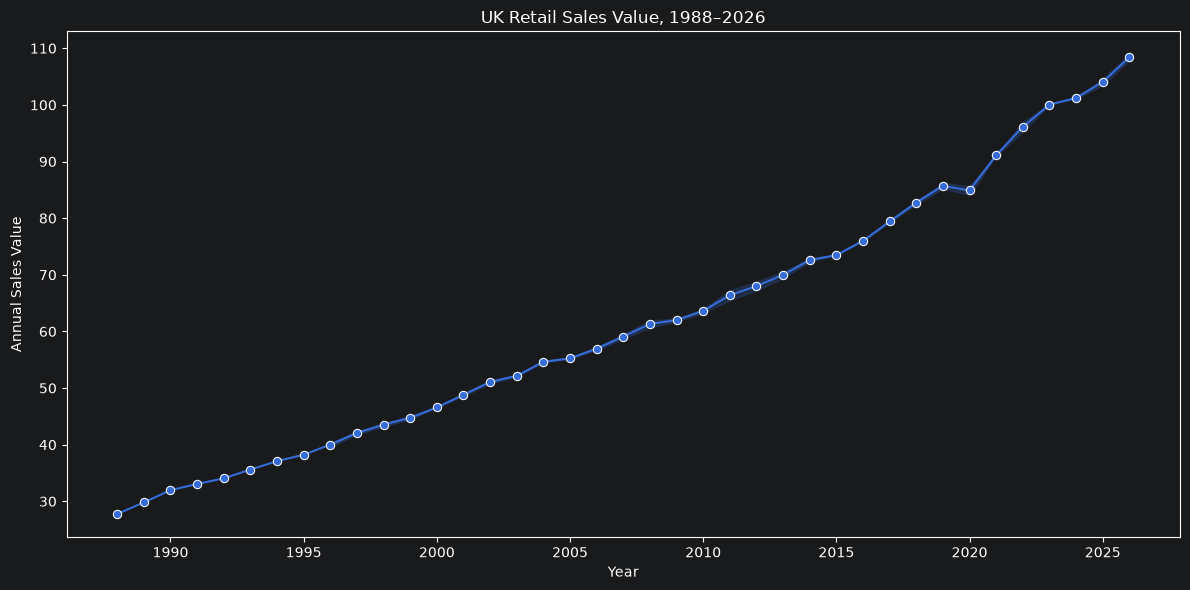

In [72]:
q2_sql = query_path.joinpath("value_trend_over_time.sql").read_text()
q2 = pd.read_sql(text(q2_sql), engine)
q2.head()
q2.isna().sum()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=q2,
    x="year",
    y="annual_sales_value",
    marker="o"
)

plt.title("UK Retail Sales Value, 1988–2026")
plt.xlabel("Year")
plt.ylabel("Annual Sales Value")

plt.tight_layout()
plt.savefig(output_path / "value_trend.png", dpi=300, bbox_inches="tight")
plt.show()

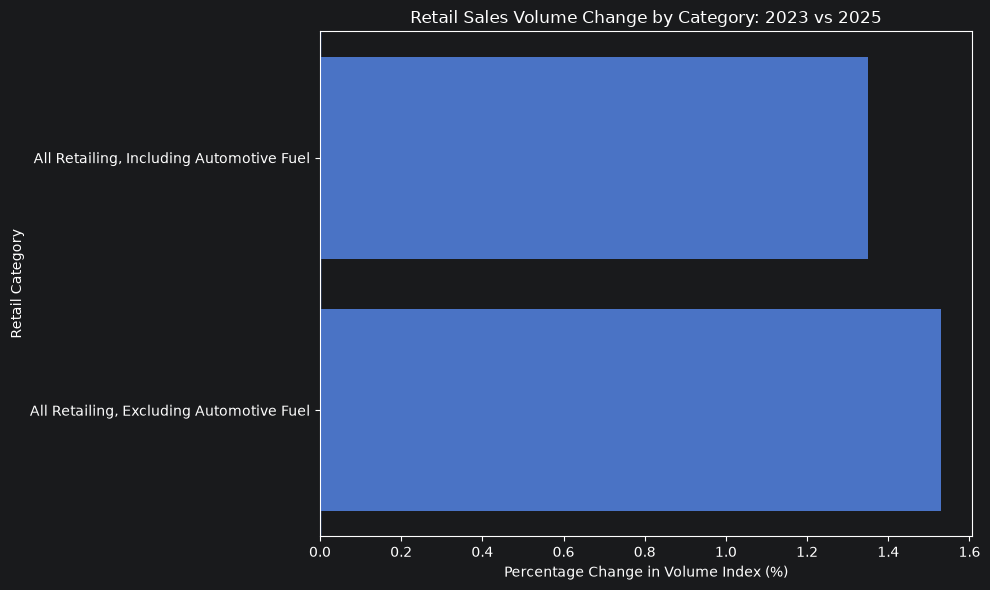

In [73]:
q3_sql = query_path.joinpath("2025_vs_2023.sql").read_text()
q3 = pd.read_sql(text(q3_sql), engine)

plt.figure(figsize=(10, 6))
q3_plot = q3.sort_values("percentage_difference", ascending=True)
sns.barplot(data=q3_plot, x="percentage_difference", y="category_name")
plt.axvline(0, linewidth=1)

plt.title("Retail Sales Volume Change by Category: 2023 vs 2025")
plt.xlabel("Percentage Change in Volume Index (%)")
plt.ylabel("Retail Category")

plt.tight_layout()
plt.savefig(output_path / "2025_vs_2023_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

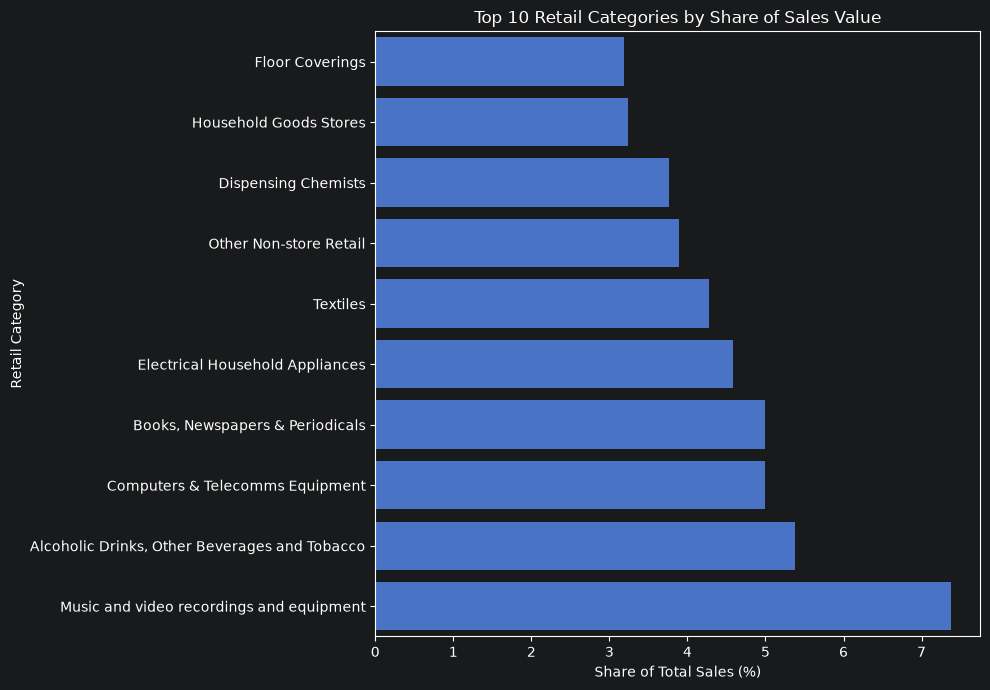

In [74]:
q4_sql = query_path.joinpath("category_value_contribution.sql").read_text()
q4 = pd.read_sql(text(q4_sql), engine)
q4.head(10)

top_categories = (q4.head(10).sort_values("total_percentage", ascending=True))
plt.figure(figsize=(10, 7))
sns.barplot(data=top_categories, x="total_percentage", y="category_name")

plt.title("Top 10 Retail Categories by Share of Sales Value")
plt.xlabel("Share of Total Sales (%)")
plt.ylabel("Retail Category")

plt.tight_layout()
plt.savefig(output_path / "category_contribution.png", dpi=300, bbox_inches="tight")
plt.show()

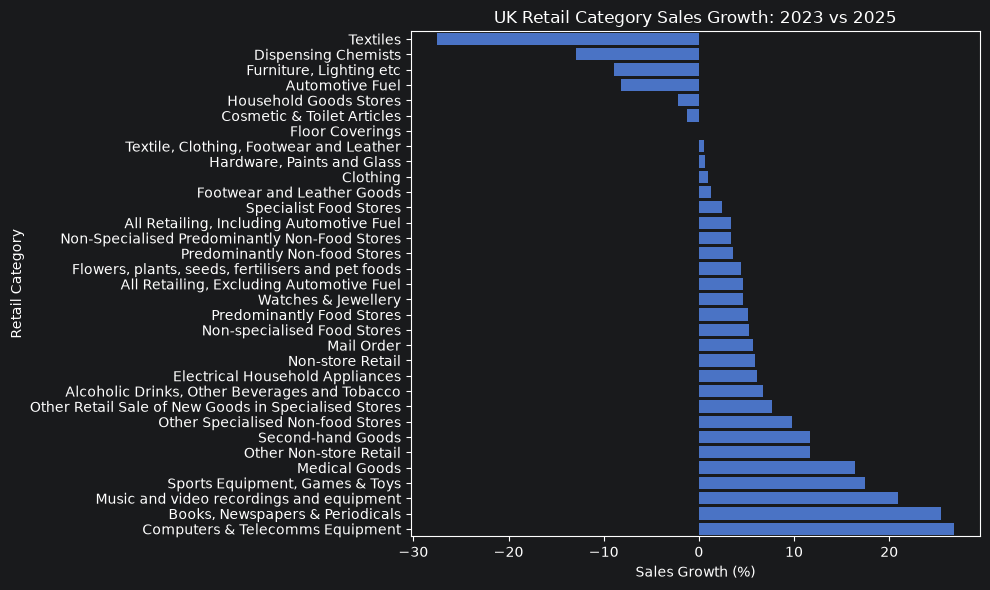

In [75]:
q5_sql = query_path.joinpath("category_growth_ranking.sql").read_text()
q5 = pd.read_sql(text(q5_sql), engine)
q5.head(10)

q5_plot = q5.sort_values("growth_percentage", ascending=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=q5_plot, x="growth_percentage", y="category_name")

plt.title("UK Retail Category Sales Growth: 2023 vs 2025")
plt.xlabel("Sales Growth (%)")
plt.ylabel("Retail Category")

plt.tight_layout()
plt.savefig(output_path / "category_growth.png", dpi=300, bbox_inches="tight")
plt.show()

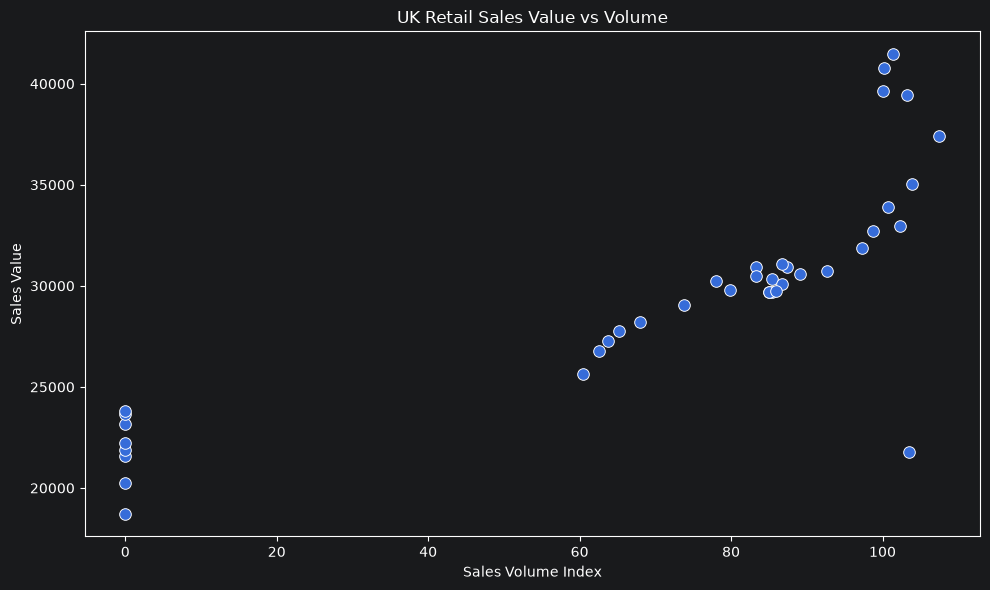

In [76]:
q6_sql = query_path.joinpath("value_vs_volume_divergence.sql").read_text()
q6 = pd.read_sql(text(value_vs_volume_sql), engine)
q6.head()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=value_vs_volume, x="volume_index", y="sales_value", s=70)

plt.title("UK Retail Sales Value vs Volume")
plt.xlabel("Sales Volume Index")
plt.ylabel("Sales Value")

plt.tight_layout()
plt.savefig(output_path / "value_vs_volume.png", dpi=300, bbox_inches="tight")
plt.show()